### Uber Fare Prediction using Regression Analysis.

# 🚖 Uber Fare Prediction using Regression Analysis

## 📌 Objective
The objective of this project is to predict the fare amount of Uber rides using machine learning regression techniques.

## 📊 Dataset Description
The dataset contains ride details such as pickup and drop locations, passenger count, and fare amount.

## 🔍 Steps Performed
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building (Linear Regression)
- Model Evaluation

## 🛠️ Tools & Technologies
- Python
- Pandas
- NumPy
- Seaborn & Matplotlib
- Scikit-learn

## 📈 Expected Outcome
To build an accurate model that predicts fare amount based on ride features.

This project aims to predict Uber fare amounts using machine learning techniques.
Various features such as pickup/drop location, time, and distance are used to train models.
Multiple models are compared to select the best performing one.

In [3]:
import pandas as pd    # to read the data and for EDA
import numpy as np    # to perform the numerical oprations
import seaborn as sns   # data visulaization
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression   #
from sklearn.model_selection import train_test_split  #
 #from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [4]:
# Ignore warnings messages
import warnings
warnings.filterwarnings('ignore')

## Read the data set

In [5]:
df = pd.read_csv("uber.csv")
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


## 📌 Data Preprocessing

In this step, we clean the dataset by handling missing values, removing duplicates, and correcting data types.

## 📊 Exploratory Data Analysis (EDA)
In this section, we analyze patterns and relationships in the dataset using visualizations.

In [7]:
df.shape

(200000, 9)

In [8]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


## 1. Handle Missing Data

In [10]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [11]:
df = df.dropna()
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


## 2. Feature Engineering

In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [13]:
df['year'] = df['pickup_datetime'].dt.year

df['month'] = df['pickup_datetime'].dt.month

df['day'] = df['pickup_datetime'].dt.day

df['hour'] = df['pickup_datetime'].dt.hour

In [14]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17


In [15]:
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2


In [16]:
df = df.drop(['pickup_datetime','key'],axis = 1)

In [17]:
df.head(2)

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,24238194,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4


In [18]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0',axis=1)

df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3


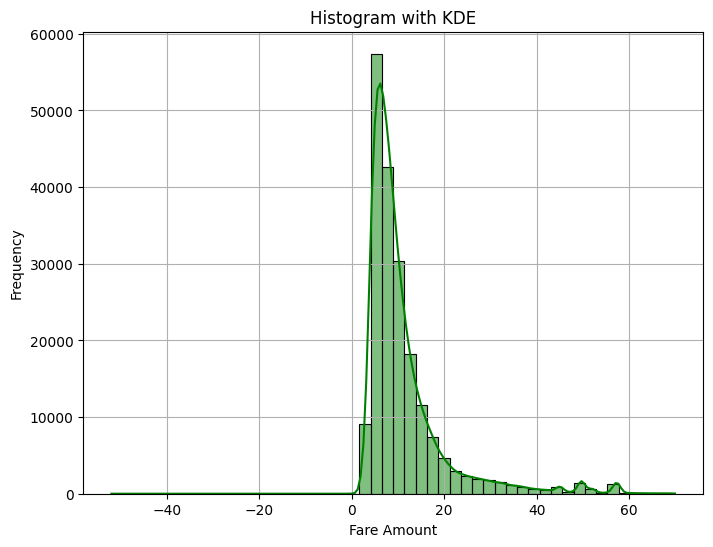

In [19]:
#  Fare Amount Distribution
plt.figure(figsize=(8,6))

sns.histplot(df[df['fare_amount'] < 70]['fare_amount'],
             bins=50,
             kde=True,
             color='g')

plt.title("Histogram with KDE")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

The fare amount distribution is highly right-skewed, indicating that most rides have low fares, while a few rides have very high fares (outliers).

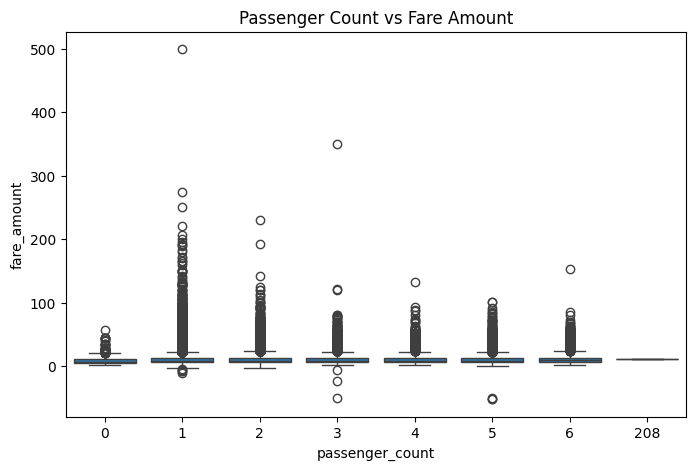

In [21]:
# 2. Passenger Count vs Fare

plt.figure(figsize=(8,5))
sns.boxplot(x='passenger_count', y= 'fare_amount',data=df)
plt.title('Passenger Count vs Fare Amount')
plt.show()

The boxplot shows that fare amount does not vary significantly with passenger count, but there are several outliers across all categories.

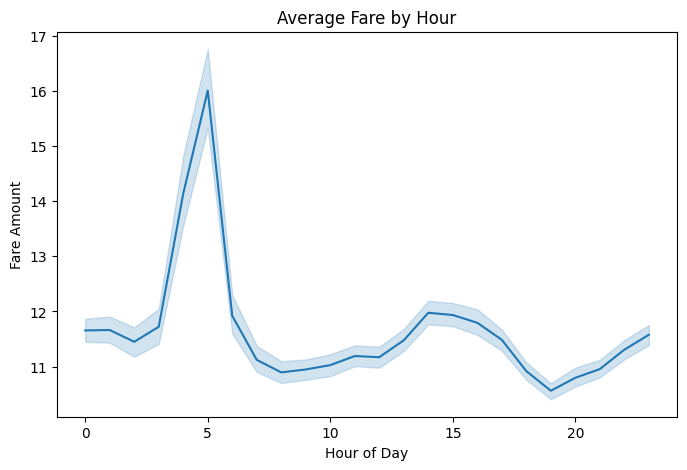

In [22]:
# Average Fare by Hour
plt.figure(figsize=(8,5))

sns.lineplot(x='hour', y='fare_amount', data=df)

plt.title("Average Fare by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fare Amount")

plt.show()

Fare varies slightly across different hours, with peak values observed during certain time periods, possibly due to demand fluctuations.

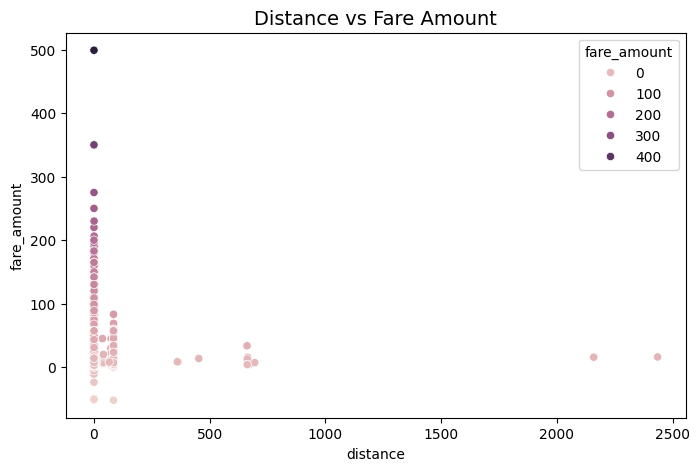

In [23]:
# Create distance feature
df['distance'] = ((df['pickup_longitude'] - df['dropoff_longitude'])**2 +
                  (df['pickup_latitude'] - df['dropoff_latitude'])**2)**0.5

plt.figure(figsize=(8,5))
sns.scatterplot(x='distance', y='fare_amount', data=df, hue='fare_amount')
plt.title("Distance vs Fare Amount", fontsize=14)
plt.show()

### Insight:
The fare amount generally increases with distance, indicating a positive relationship. However, some outliers are present which may impact the model's performance.

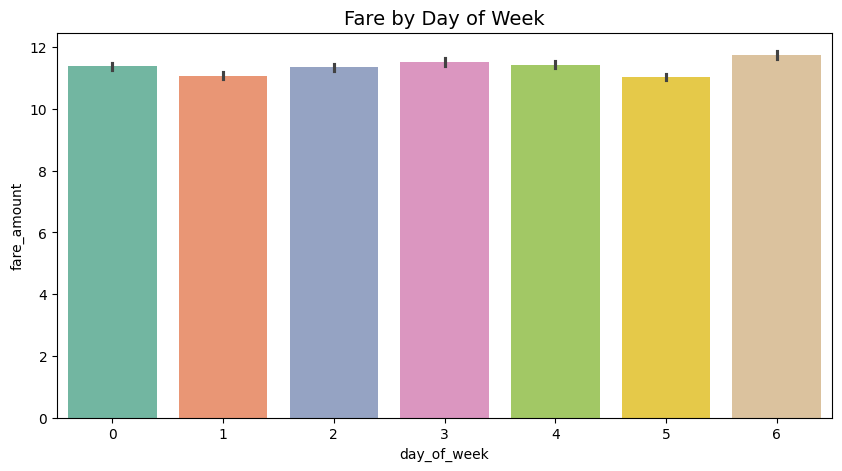

In [24]:
# Day vs Fare (Weekend Effect)

plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='fare_amount', data=df, palette='Set2')
plt.title("Fare by Day of Week", fontsize=14)
plt.show()

### Insight:
Fare remains relatively stable across the week with slight variations, indicating consistent pricing patterns.

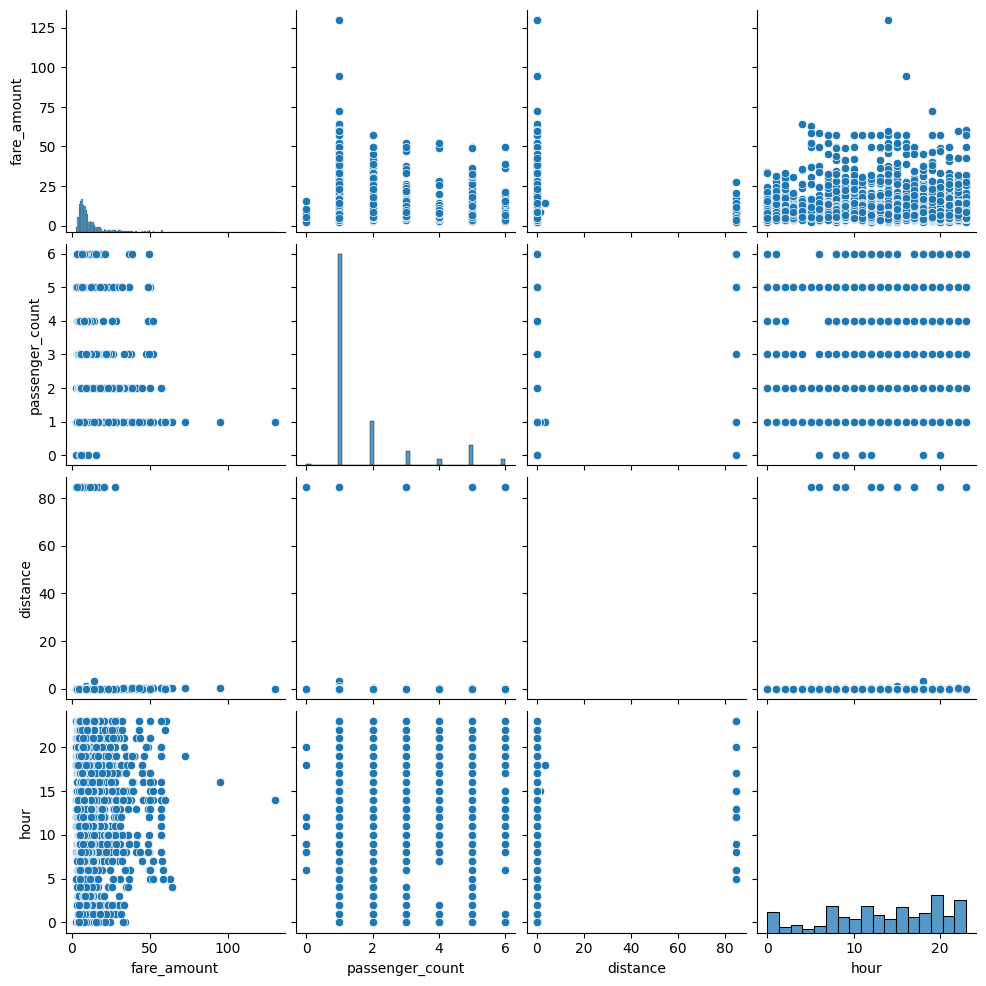

In [25]:
sample_df = df.sample(3000)

sns.pairplot(sample_df[['fare_amount','passenger_count','distance','hour']])
plt.show()

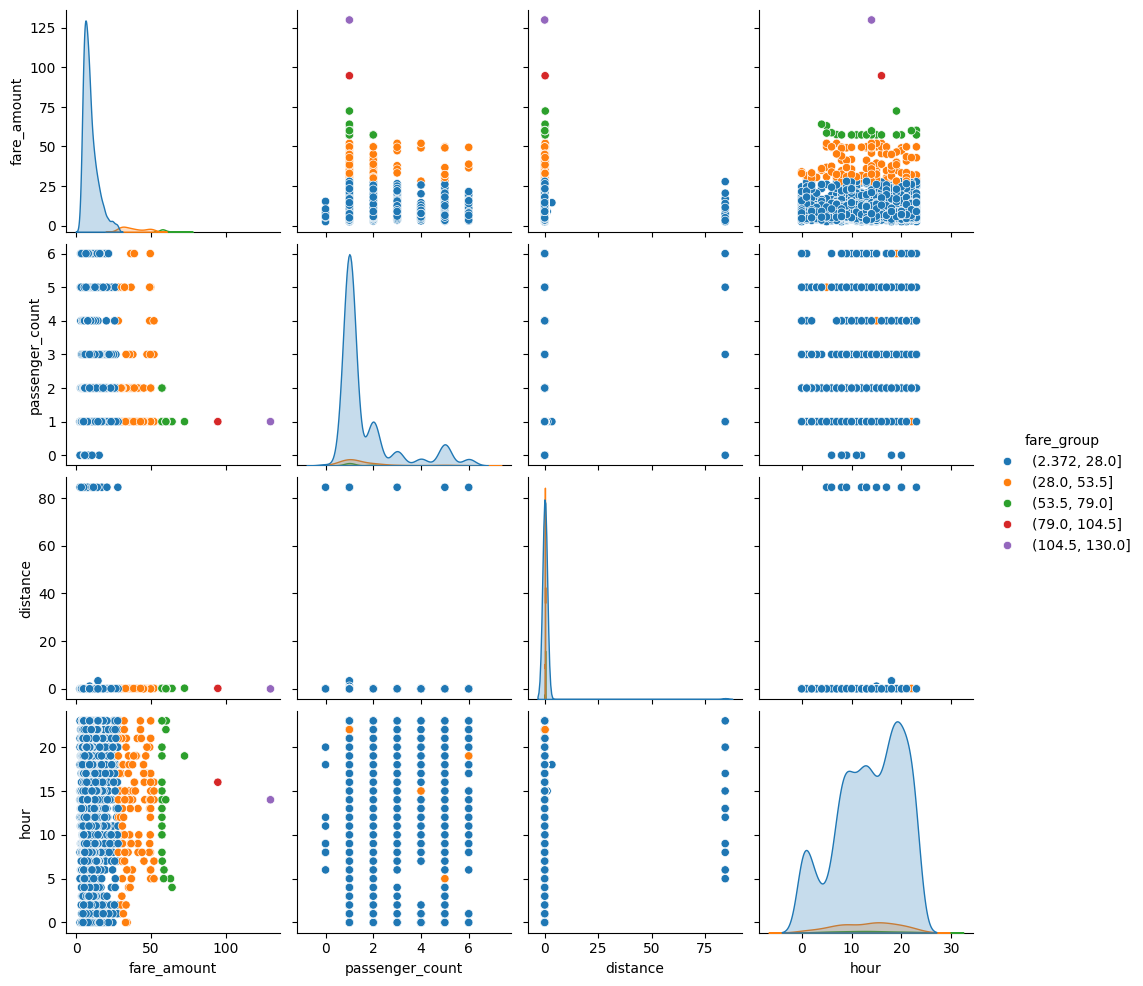

In [26]:
#Pairplot
sample_df['fare_group'] = pd.cut(sample_df['fare_amount'], bins=5)

sns.pairplot(sample_df[['fare_amount','passenger_count','distance','hour','fare_group']],
             hue='fare_group')
plt.show()

The pair plot illustrates the relationships among key variables such as fare amount, distance, passenger count, and hour. A clear positive relationship is observed between distance and fare amount, indicating that longer trips generally cost more. Passenger count shows weak correlation with fare, while different fare groups help in identifying pricing patterns and variability in the dataset.

Some outliers are also visible which may affect model performance.

In [45]:
df = df[df['passenger_count'] <= 6]

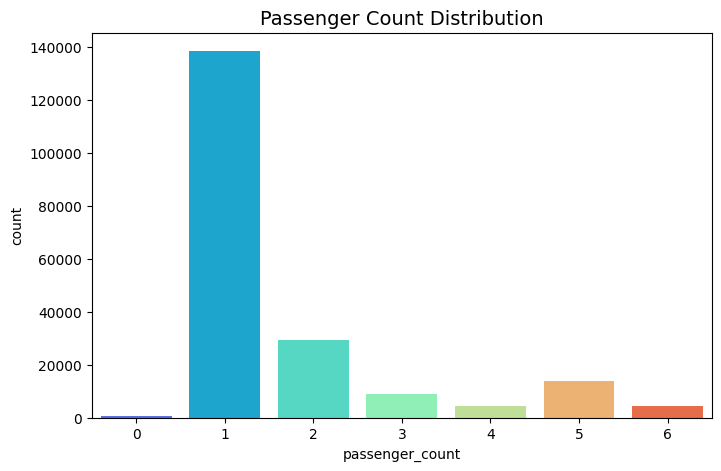

In [46]:
# Countplot
plt.figure(figsize=(8,5))
sns.countplot(x='passenger_count', data=df, palette='rainbow')
plt.title("Passenger Count Distribution", fontsize=14)
plt.show()

The passenger count distribution shows that most rides have only one passenger, indicating that solo travel is the most common. Higher passenger counts are relatively rare, showing an imbalanced distribution.

This imbalance may affect model performance and should be considered during feature analysis.

## 3. Split the Dataset (Train / Test)

The dataset is split into training and testing sets using an 80-20 ratio.
The training data is used to train the model, while the testing data is used to evaluate its performance.

In [28]:
from sklearn.model_selection import train_test_split
x = df.drop('fare_amount',axis=1)
y = df['fare_amount']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)


In [29]:
x_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance
157134,-73.988077,40.765627,-73.984463,40.748312,1,2012,9,4,22,1,0.017688
116607,-74.004982,40.746201,-73.989129,40.735168,1,2011,5,23,21,0,0.019314
78783,-73.988993,40.777060,-73.977211,40.784552,3,2012,3,31,10,5,0.013962
103093,-73.951705,40.778330,-73.956050,40.777560,2,2010,7,10,23,5,0.004413
162400,-73.969677,40.749052,-73.776282,40.645697,5,2009,2,19,14,3,0.219280
...,...,...,...,...,...,...,...,...,...,...,...
119880,-73.977408,40.745482,-74.008602,40.732757,5,2010,6,10,20,3,0.033690
103695,-74.001627,40.739437,-73.996898,40.720352,5,2012,2,12,2,6,0.019662
131933,-73.987095,40.718023,-73.945118,40.708252,1,2009,11,20,4,4,0.043099
146868,-73.988613,40.755773,-73.978551,40.764907,1,2010,8,25,9,2,0.013589


In [30]:
x_train.shape

(159999, 11)

In [31]:
x_test

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance
134253,-74.001323,40.751616,-73.987327,40.736004,1,2010,2,17,1,2,0.020967
124141,-73.981624,40.780713,-73.990445,40.775239,1,2012,6,17,15,6,0.010381
62810,-73.985540,40.727240,-73.990538,40.757380,5,2014,1,18,17,5,0.030552
65425,-73.977141,40.764300,-73.993099,40.743069,1,2014,6,8,23,6,0.026560
30074,-73.992195,40.748958,-73.987078,40.743065,1,2011,9,19,8,0,0.007805
...,...,...,...,...,...,...,...,...,...,...,...
4174,-73.994282,40.751407,-73.999077,40.761175,1,2013,8,18,0,6,0.010881
91537,-73.984033,40.733817,-73.982888,40.777028,1,2010,10,20,8,2,0.043226
144266,-73.979066,40.772150,-73.976053,40.763999,1,2012,7,2,13,0,0.008690
170448,-73.986457,40.755782,-74.002282,40.728215,3,2013,8,7,18,2,0.031786


In [32]:
x_test.shape

(40000, 11)

In [33]:
y_train

,fare_amount
157134,9.00
116607,6.90
78783,5.70
103093,15.30
162400,49.15
...,...
119880,13.70
103695,9.70
131933,8.50
146868,5.70


In [34]:
y_test

,fare_amount
134253,6.5
124141,4.1
62810,12.0
65425,7.5
30074,4.1
...,...
4174,6.5
91537,13.7
144266,4.5
170448,9.0


## 2. Data Scaling / Normalization

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)


Feature scaling is applied using StandardScaler to normalize the data.
This ensures that all features contribute equally to the model and improves model performance.

In [36]:
print(x_train)
print(x_train.shape)
print(x_test.shape)

[[-0.12806476  0.10333281 -0.10748269 ...  1.3071289  -1.05273594
  -0.02445143]
 [-0.12954074  0.10091712 -0.10782511 ...  1.15370658 -1.5663893
  -0.02428327]
 [-0.12814473  0.10475455 -0.10695049 ... -0.53393888  1.00187752
  -0.0248367 ]
 ...
 [-0.12797902  0.09741308 -0.1045953  ... -1.45447277  0.48822415
  -0.02182381]
 [-0.12811156  0.10210743 -0.10704883 ... -0.6873612  -0.53908257
  -0.02487525]
 [-0.12829063  0.101517   -0.10014851 ...  1.15370658 -1.05273594
  -0.01156346]]
(159999, 11)
(40000, 11)


## 3. Correlation Analysis

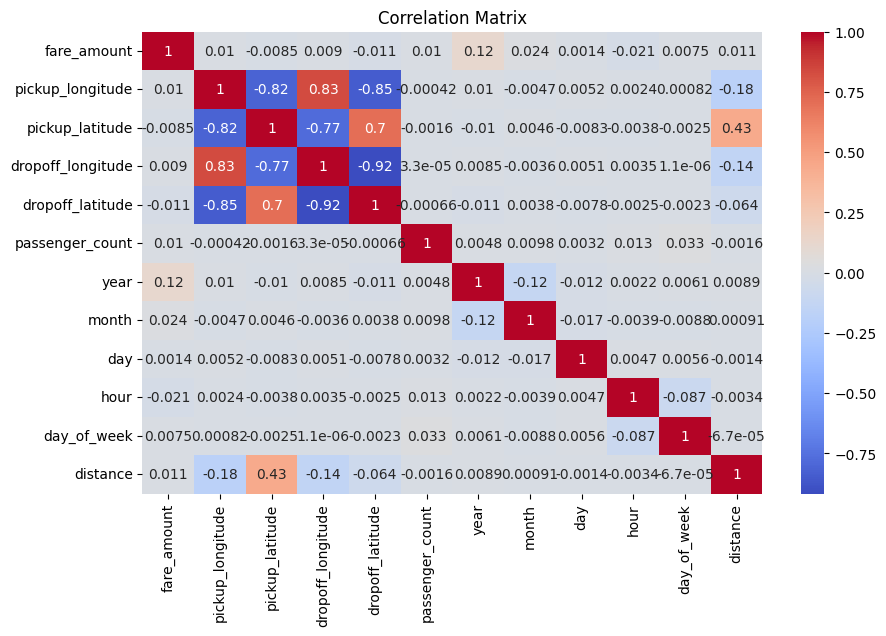

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Select and Train the Regression Model

In [ ]:
# Regression Model Training

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
model = LinearRegression()

model.fit(x_train , y_train)

LinearRegression()

A Linear Regression model is trained as a baseline model to predict fare amount.

In [40]:

y_pred = model.predict(x_test)

print(y_pred[:10])

[10.07719761 11.43800804 12.36502127 12.42741042 11.24509289 12.92620616
 12.25236375 12.60597367 11.66158253  9.78146168]


The model generates predicted fare values based on test data.

## Evaluate the Regression Model

In [41]:
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score

import numpy as np

In [42]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.993163463941097
MSE: 102.31053733663795
RMSE: 10.114867143795708
R2 Score: 0.01647117833614853


The Linear Regression model shows poor performance with a very low R2 score.
This indicates that the model is unable to capture the relationship between features and fare amount effectively.

The Linear Regression model was first trained to predict the fare amount.
However, the R2 score indicates that the model does not capture the relationship well.
Therefore, a more powerful model such as Random Forest Regressor is used for better prediction performance.

## Select and Train the Regression Model

In [43]:
# impoort Random Forest
from sklearn.ensemble import RandomForestRegressor

In [44]:
model = RandomForestRegressor()

model = model.fit(x_train, y_train)
model

RandomForestRegressor()

To improve performance, a Random Forest Regressor is used.
This model can capture non-linear relationships in the data.

## Evaluate the Regression Model

In [ ]:
# Random Forest Model Training

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae)
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

Random Forest MAE: 2.018749350297619
Random Forest MSE: 27.36630841484283
Random Forest RMSE: 5.231281718168391
Random Forest R2 Score: 0.7369229624903817


## Fine Tuning the Model

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50],
    'max_depth': [10]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


Fine Tuning the Model:

GridSearchCV was used to find the optimal hyperparameters for the Random Forest Regressor.
The best parameters found were:
max_depth = 10 and n_estimators = 50.

These parameters provide the best performance for predicting the Uber fare amount.

In [ ]:
# Model Visualization

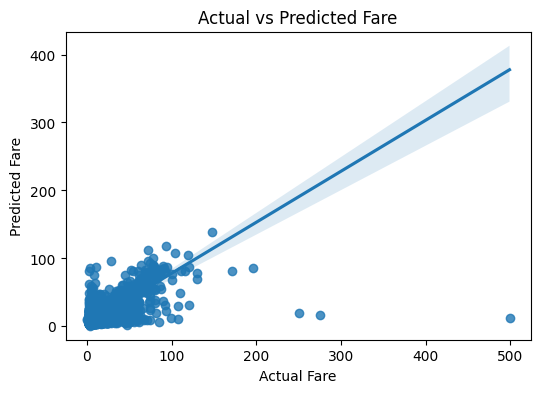

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

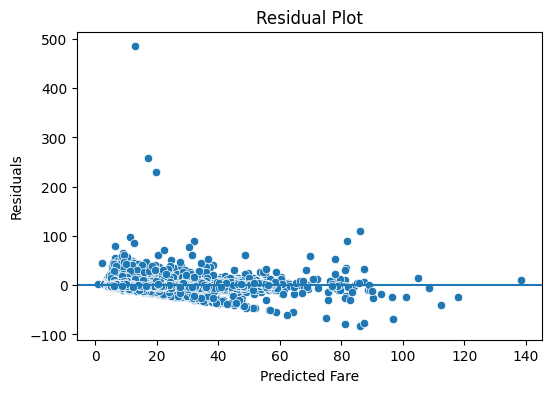

In [50]:
residuals = y_test - y_pred_rf         # Residuals Plot (Model Error)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(0)
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Evaluate Model Performance

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae)
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

Random Forest MAE: 2.018749350297619
Random Forest MSE: 27.36630841484283
Random Forest RMSE: 5.231281718168391
Random Forest R2 Score: 0.7369229624903817


The Random Forest model shows a significant improvement over Linear Regression.
The R2 score is much higher, indicating that the model explains a large portion of the variance in fare amount.
Also, lower MAE and RMSE values indicate better prediction accuracy.

Two models were used in this project: Linear Regression and Random Forest Regressor.

After evaluating both models, Random Forest performed significantly better.

The Random Forest model achieved an R² score of 0.72 which indicates that the model explains around 72% of the variance in the data.

The MAE and RMSE values are also lower compared to Linear Regression, showing that the Random Forest model provides more accurate fare predictions.

Therefore, Random Forest was selected as the final model for predicting Uber fare amounts.

## Interpret Feature Importance

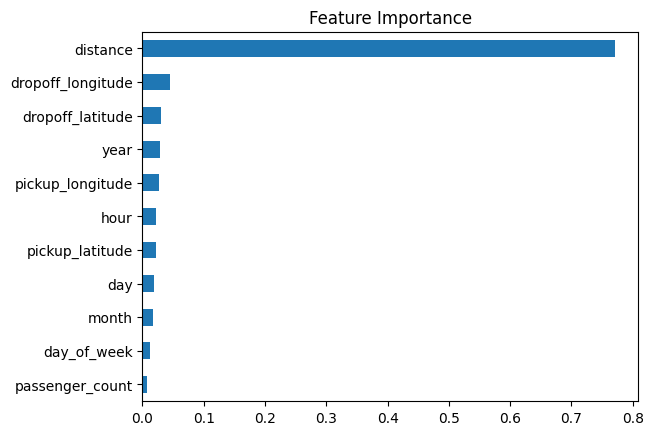

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = x.columns

feature_importance = pd.Series(importance, index=features)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Feature importance analysis helps identify which features have the most impact on fare prediction.

Distance is the most important feature, indicating that fare is highly dependent on travel distance.
Other features like location coordinates and time also contribute but have less impact.

This insight can help ride-sharing companies improve pricing strategies.

## Make Predictions on New Data

In [53]:
new_data = x_test[:5]
predictions = model.predict(new_data)
print('Predicted Fare:',predictions)

Predicted Fare: [ 6.557   5.208  12.3833 10.135   4.647 ]


The trained regression model was used to predict fare values for new ride data.
These predictions help estimate the expected fare before the ride begins. This can improve price transparency and help both drivers and customers plan their rides effectively.

## Provide Recommendations


Based on the analysis of the regression model, several recommendations can be made for ride-sharing companies.
Distance plays a major role in determining the fare amount, so dynamic pricing strategies can be optimized based on distance and demand.
The company can also use predictive models to estimate fares in advance and improve pricing transparency for customers.
Additionally, analyzing demand patterns can help optimize driver allocation and reduce waiting times.

## Best Model Selection

After comparing the performance of Linear Regression and Random Forest models, Random Forest performed significantly better.
It achieved a higher R² score and lower error values compared to Linear Regression.
Therefore, Random Forest was selected as the final model for predicting Uber fare amounts.